# 09 · Recomendación personalizada y explicable multimodal de barrios

El usuario puede:

- Elegir un **destino habitual**
- Elegir el **modo de transporte** que utilizará (*TRANSIT, WALK, BICYCLE o CAR*)
- Asignar distinta importancia al **precio** y al **tiempo diario de desplazamiento**
- Aplicar límites de precio, presupuesto orientativo, tiempo y fiabilidad de la estimación iNmobiliaria
- Recalcular el frente de Pareto dentro de las alternativas compatibles
- Obtener un ranking reproducible y explicable
- Comparar perfiles predefinidos
- Analizar la sensibilidad frente a cambios en los pesos
- Auditar y validar automáticamente el comportamiento del motor

Los dos objetivos principales continúan siendo minimizar: *price_m2_for_recommender; commute_daily_minutes*

El modo de transporte **no** se trata como un tercer objetivo. Funciona como una preferencia categórica que condiciona el conjunto de alternativas comparables. Cada ranking se calcula dentro de una combinación *destino × modo*.

**NOTA DEL PRESUPUESTO:** *precio por m² × superficie de referencia* es una aproximación territorial. No representa el precio de una vivienda concreta.

## 1. Importaciones

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 180)

## 2. Localización del proyecto y archivos

El notebook reutiliza *data/results/pareto_by_destination_mode.csv*. Así se separa claramente el cálculo general de Pareto de la personalización del ranking.

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )

In [4]:
PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PARETO_RESULTS_PATH = RESULTS_DIR / "pareto_by_destination_mode.csv"

RECOMMENDATION_EXAMPLE_PATH = (
    RESULTS_DIR / "personalized_recommendation_multimodal_example.csv"
)
FILTER_AUDIT_PATH = (
    RESULTS_DIR / "personalized_recommendation_multimodal_filter_audit.csv"
)
PROFILE_DEFINITIONS_PATH = (
    RESULTS_DIR / "recommendation_profiles.csv"
)
PROFILE_COMPARISON_PATH = (
    RESULTS_DIR / "profile_recommendation_comparison_by_destination_mode.csv"
)
USER_CASE_RECOMMENDATIONS_PATH = (
    RESULTS_DIR / "user_case_recommendations_multimodal.csv"
)
USER_CASE_AUDIT_PATH = (
    RESULTS_DIR / "user_case_filter_audit_multimodal.csv"
)
SENSITIVITY_EXAMPLE_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_multimodal_example.csv"
)
SENSITIVITY_INTERVALS_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_multimodal_example_intervals.csv"
)
SENSITIVITY_ALL_GROUPS_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_all_destination_modes.csv"
)
SENSITIVITY_INTERVALS_ALL_GROUPS_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_intervals_all_destination_modes.csv"
)
SENSITIVITY_SUMMARY_PATH = (
    RESULTS_DIR / "recommendation_weight_sensitivity_summary_by_destination_mode.csv"
)
VALIDATION_PATH = (
    RESULTS_DIR / "recommendation_engine_multimodal_validation.csv"
)
FINAL_SUMMARY_PATH = (
    RESULTS_DIR / "recommendation_engine_multimodal_summary.csv"
)

In [5]:
if not PARETO_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "No existe pareto_by_destination_mode.csv. "
        "Ejecuta primero el notebook 08."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Entrada:", PARETO_RESULTS_PATH)
print("Resultados:", RESULTS_DIR)

Raíz del proyecto: /home/aclaver/TFG-INFO
Entrada: /home/aclaver/TFG-INFO/data/results/pareto_by_destination_mode.csv
Resultados: /home/aclaver/TFG-INFO/data/results


## 3. Carga, contrato y validación inicial de los datos

In [6]:
pareto_data = pd.read_csv(PARETO_RESULTS_PATH)

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

EXPECTED_MODES = {
    "TRANSIT": "Transporte público",
    "WALK": "A pie",
    "BICYCLE": "Bicicleta",
    "CAR": "Coche",
}

GROUP_KEY = [
    "destination_id",
    "transport_mode",
]

ALTERNATIVE_KEY = [
    "zone_key",
    "destination_id",
    "transport_mode",
]

REQUIRED_COLUMNS = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
    "price_normalized",
    "time_normalized",
]

missing_columns = sorted(
    set(REQUIRED_COLUMNS) - set(pareto_data.columns)
)

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias en pareto_by_destination_mode.csv: "
        f"{missing_columns}"
    )

In [7]:
def parse_boolean_series(
    series: pd.Series,
    column_name: str,
) -> pd.Series:
    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    true_values = {"true", "1", "yes", "y", "si", "sí"}
    false_values = {"false", "0", "no", "n"}
    valid_values = true_values | false_values

    invalid = (
        normalized.notna()
        & ~normalized.isin(valid_values)
    )

    if invalid.any():
        examples = sorted(
            normalized.loc[invalid]
            .dropna()
            .unique()
            .tolist()
        )[:10]

        raise ValueError(
            f"Valores no reconocidos en {column_name}: {examples}"
        )

    return normalized.isin(true_values).fillna(False)


for column in [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
]:
    pareto_data[column] = (
        pareto_data[column]
        .astype("string")
        .str.strip()
    )

pareto_data["transport_mode"] = (
    pareto_data["transport_mode"]
    .str.upper()
)

pareto_data["is_pareto"] = parse_boolean_series(
    pareto_data["is_pareto"],
    "is_pareto",
)

numeric_columns = [
    PRICE_COLUMN,
    TIME_COLUMN,
    "price_normalized",
    "time_normalized",
    "price_reliability_score",
    "dominated_by_count",
]

for column in numeric_columns:
    if column in pareto_data.columns:
        pareto_data[column] = pd.to_numeric(
            pareto_data[column],
            errors="coerce",
        )

In [8]:
duplicate_alternatives = pareto_data.duplicated(
    subset=ALTERNATIVE_KEY,
    keep=False,
)

if duplicate_alternatives.any():
    display(
        pareto_data.loc[
            duplicate_alternatives,
            [
                *ALTERNATIVE_KEY,
                "neighborhood_name",
                "destination_name",
                "transport_mode_label",
            ],
        ].sort_values(ALTERNATIVE_KEY)
    )
    raise ValueError(
        "Hay combinaciones barrio–destino–modo duplicadas."
    )

invalid_objectives = pareto_data.loc[
    pareto_data[[PRICE_COLUMN, TIME_COLUMN]]
    .isna()
    .any(axis=1)
    | (
        pareto_data[[PRICE_COLUMN, TIME_COLUMN]]
        <= 0
    ).any(axis=1)
]

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            [
                *ALTERNATIVE_KEY,
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ]
    )
    raise ValueError(
        "Existen precios o tiempos no válidos."
    )

normalized_valid = (
    pareto_data[
        ["price_normalized", "time_normalized"]
    ]
    .ge(-1e-9)
    .all()
    .all()
    and pareto_data[
        ["price_normalized", "time_normalized"]
    ]
    .le(1 + 1e-9)
    .all()
    .all()
)

if not normalized_valid:
    raise ValueError(
        "Las variables normalizadas no están en [0, 1]."
    )

modes_present = set(
    pareto_data["transport_mode"]
    .dropna()
    .astype(str)
    .unique()
)

if modes_present != set(EXPECTED_MODES):
    raise ValueError(
        "Los modos disponibles no coinciden con los cuatro esperados. "
        f"Presentes: {sorted(modes_present)}"
    )

for mode, expected_label in EXPECTED_MODES.items():
    labels = set(
        pareto_data.loc[
            pareto_data["transport_mode"].eq(mode),
            "transport_mode_label",
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    if labels != {expected_label}:
        raise ValueError(
            f"Etiqueta inconsistente para {mode}: {sorted(labels)}"
        )

print("Dimensiones:", pareto_data.shape)
print("Barrios:", pareto_data["zone_key"].nunique())
print("Destinos:", pareto_data["destination_id"].nunique())
print("Modos:", pareto_data["transport_mode"].nunique())
print(
    "Grupos destino–modo:",
    pareto_data[GROUP_KEY].drop_duplicates().shape[0],
)

display(pareto_data.head())

Dimensiones: (1457, 158)
Barrios: 129
Destinos: 3
Modos: 4
Grupos destino–modo: 12


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,destination_name,transport_mode,transport_mode_label,service_date,morning_requested_datetime,morning_route_status,morning_routing_errors_json,morning_request_error,evening_requested_datetime,evening_route_status,evening_routing_errors_json,evening_request_error,morning_start_datetime,morning_end_datetime,morning_all_modes,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_distance_meters,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_all_modes,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_distance_meters,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,route_status,route_available,no_route_scenarios,commute_daily_minutes,commute_daily_distance_meters,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_walk_distance_meters,commute_daily_transfers,route_missing_reason,usable_for_pareto_knn,model_readiness_status,is_pareto,dominated_by_count,price_normalized,time_normalized,distance_to_ideal,pareto_balance_rank
0,MAD-011,Palacio,Centro,True,True,available,308,297,11,96.43,3.57,2.67,297,771118.19,540000.0,349000.0,886000.0,537000.0,150000.0,15000000.0,7003.76,6614.32,5789.47,7480.00,1690.53,2142.05,25.56,6462.96,6898.15,435.19,6.58,113.14,297,2000,0.95,calculated,104.48,90.0,50.0,140.0,90.0,25.0,666.0,2.32,2.0,280,17,94.28,1.68,2.0,59,238,19.87,0.7162,71.62,296,1,99.66,0.7306,73.06,297,0,100.00,94.44,91.27,74.21,88.12,high,La estimación presenta una estabilidad alta en comparación con el resto de barrios.,residential_sale,asking_price,u

## 3.1. Cobertura por destino y modo

El archivo incluye solo las alternativas válidas para el análisis del notebook 08. Como no todos los destinos y modos tienen la misma cobertura, los casos sin ruta simplemente se mantienen fuera, sin inventar ni rellenar tiempos.

In [9]:
coverage_by_destination_mode = (
    pareto_data
    .groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        available_neighborhoods=("zone_key", "nunique"),
        pareto_neighborhoods=("is_pareto", "sum"),
        median_price_eur_m2=(PRICE_COLUMN, "median"),
        median_commute_daily_minutes=(TIME_COLUMN, "median"),
    )
    .sort_values(
        ["destination_id", "transport_mode"]
    )
    .reset_index(drop=True)
)

numeric_coverage_columns = (
    coverage_by_destination_mode
    .select_dtypes(include="number")
    .columns
)

coverage_by_destination_mode[
    numeric_coverage_columns
] = (
    coverage_by_destination_mode[
        numeric_coverage_columns
    ].round(2)
)

display(coverage_by_destination_mode)

,destination_id,destination_name,transport_mode,transport_mode_label,available_neighborhoods,pareto_neighborhoods,median_price_eur_m2,median_commute_daily_minutes
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,14,4878.72,68.35
1,DEST_001,Puerta del Sol,CAR,Coche,121,14,4789.99,25.17
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,13,4736.60,117.60
3,DEST_001,Puerta del Sol,WALK,A pie,128,16,4884.51,168.92
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,16,4878.72,75.62
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,18,4789.99,25.08
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,10,4787.97,120.80
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,18,4878.72,192.80
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,4,4878.72,174.52
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,4,4789.99,38.37


## 4. Catálogos y perfiles predefinidos

Los perfiles sirven como casos reproducibles; el motor acepta cualquier combinación no negativa de pesos.

In [10]:
destination_catalog = (
    pareto_data[
        ["destination_id", "destination_name"]
    ]
    .drop_duplicates()
    .sort_values(
        ["destination_name", "destination_id"]
    )
    .reset_index(drop=True)
)

mode_catalog = (
    pareto_data[
        ["transport_mode", "transport_mode_label"]
    ]
    .drop_duplicates()
    .sort_values("transport_mode")
    .reset_index(drop=True)
)

destination_mode_catalog = (
    pareto_data[
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["destination_id", "transport_mode"]
    )
    .reset_index(drop=True)
)

PREDEFINED_PROFILES = {
    "price_priority": {
        "profile_name": "Prioridad al precio",
        "price_weight": 0.75,
        "time_weight": 0.25,
    },
    "balanced": {
        "profile_name": "Perfil equilibrado",
        "price_weight": 0.50,
        "time_weight": 0.50,
    },
    "time_priority": {
        "profile_name": "Prioridad al tiempo",
        "price_weight": 0.25,
        "time_weight": 0.75,
    },
}

profile_definitions = pd.DataFrame(
    [
        {
            "profile_id": profile_id,
            **profile,
        }
        for profile_id, profile
        in PREDEFINED_PROFILES.items()
    ]
)



In [11]:
display(destination_catalog)

,destination_id,destination_name
0,DEST_002,Nuevos Ministerios
1,DEST_001,Puerta del Sol
2,DEST_003,UC3M Campus de Leganés


In [12]:
display(mode_catalog)

,transport_mode,transport_mode_label
0,BICYCLE,Bicicleta
1,CAR,Coche
2,TRANSIT,Transporte público
3,WALK,A pie


In [13]:
display(profile_definitions)

,profile_id,profile_name,price_weight,time_weight
0,price_priority,Prioridad al precio,0.75,0.25
1,balanced,Perfil equilibrado,0.50,0.50
2,time_priority,Prioridad al tiempo,0.25,0.75


## 5. Metodología del ranking

Para una solicitud concreta, el motor:

1. Resuelve destino y modo
2. Selecciona únicamente ese grupo **destino × modo**
3. Aplica las restricciones duras
4. Recalcula Pareto dentro del conjunto compatible
5. Calcula una puntuación ponderada con las normalizaciones del notebook 08
6. Aplica desempates reproducibles
7. Devuelve el *top_n*, una explicación y la auditoría de filtros

La puntuación es:

***Puntuación = peso del precio x precio normalizado + peso del tiempo x tiempo normalizado***
 **NOTA:** peso del precio + peso del tiempo = 1


**Cuanto menor es la puntuación, mejor encaja la alternativa.**

Las normalizaciones permanecen fijadas por grupo *destino × modo*. Aplicar o retirar filtros no modifica artificialmente la escala de referencia. Las puntuaciones de grupos distintos no se utilizan para ordenar conjuntamente modos diferentes.

In [14]:
def pareto_mask_minimization(
    values: np.ndarray,
) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    if values.ndim != 2:
        raise ValueError(
            "La matriz de objetivos debe ser bidimensional."
        )

    if np.isnan(values).any():
        raise ValueError(
            "No se puede calcular Pareto con NaN."
        )

    efficient = np.ones(
        len(values),
        dtype=bool,
    )

    for index in range(len(values)):
        dominated = (
            np.all(
                values <= values[index],
                axis=1,
            )
            & np.any(
                values < values[index],
                axis=1,
            )
        )

        if dominated.any():
            efficient[index] = False

    return efficient


def min_max_normalize(
    series: pd.Series,
) -> pd.Series:
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).astype(float)

    minimum = values.min()
    maximum = values.max()

    if np.isclose(maximum, minimum):
        return pd.Series(
            np.zeros(len(values)),
            index=series.index,
            dtype=float,
        )

    return (
        (values - minimum)
        / (maximum - minimum)
    )


def normalize_weights(
    price_weight: float,
    time_weight: float,
) -> tuple[float, float]:
    weights = np.asarray(
        [price_weight, time_weight],
        dtype=float,
    )

    if not np.isfinite(weights).all():
        raise ValueError(
            "Los pesos deben ser finitos."
        )

    if (weights < 0).any():
        raise ValueError(
            "Los pesos no pueden ser negativos."
        )

    total = weights.sum()

    if np.isclose(total, 0):
        raise ValueError(
            "Al menos un peso debe ser positivo."
        )

    return (
        float(weights[0] / total),
        float(weights[1] / total),
    )


def positive_value_or_none(
    value: float | None,
    label: str,
) -> float | None:
    if value is None:
        return None

    value = float(value)

    if not np.isfinite(value) or value <= 0:
        raise ValueError(
            f"{label} debe ser positivo."
        )

    return value

In [15]:
def resolve_destination(
    data: pd.DataFrame,
    destination: str | int,
) -> tuple[str, str]:
    catalog = (
        data[
            ["destination_id", "destination_name"]
        ]
        .drop_duplicates()
        .copy()
    )

    destination_text = (
        str(destination)
        .strip()
        .casefold()
    )

    id_match = (
        catalog["destination_id"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(destination_text)
    )

    name_match = (
        catalog["destination_name"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(destination_text)
    )

    matches = catalog.loc[
        id_match | name_match
    ]

    if matches.empty:
        available = ", ".join(
            catalog["destination_name"]
            .sort_values()
            .astype(str)
            .tolist()
        )

        raise KeyError(
            f"No existe el destino '{destination}'. "
            f"Disponibles: {available}"
        )

    if len(matches) > 1:
        raise ValueError(
            "El destino no es unívoco. "
            "Utiliza destination_id."
        )

    selected = matches.iloc[0]

    return (
        str(selected["destination_id"]),
        str(selected["destination_name"]),
    )


def resolve_transport_mode(
    data: pd.DataFrame,
    transport_mode: str,
) -> tuple[str, str]:
    catalog = (
        data[
            ["transport_mode", "transport_mode_label"]
        ]
        .drop_duplicates()
        .copy()
    )

    mode_text = (
        str(transport_mode)
        .strip()
        .casefold()
    )

    code_match = (
        catalog["transport_mode"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(mode_text)
    )

    label_match = (
        catalog["transport_mode_label"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(mode_text)
    )

    matches = catalog.loc[
        code_match | label_match
    ]

    if matches.empty:
        available = ", ".join(
            (
                catalog["transport_mode"].astype(str)
                + " ("
                + catalog["transport_mode_label"].astype(str)
                + ")"
            )
            .sort_values()
            .tolist()
        )

        raise KeyError(
            f"No existe el modo '{transport_mode}'. "
            f"Disponibles: {available}"
        )

    if len(matches) > 1:
        raise ValueError(
            "El modo no es unívoco. "
            "Utiliza transport_mode."
        )

    selected = matches.iloc[0]

    return (
        str(selected["transport_mode"]),
        str(selected["transport_mode_label"]),
    )

### 5.1. Comprobación independiente de Pareto y normalización

Antes de personalizar, se verifica nuevamente que las etiquetas Pareto y las normalizaciones heredadas del notebook 08 coinciden con un cálculo independiente dentro de cada grupo destino–modo.

In [16]:
normalization_violations = []
pareto_label_violations = []

for (
    destination_id,
    transport_mode,
), group in pareto_data.groupby(
    GROUP_KEY,
    sort=True,
):
    group = group.copy()

    expected_price_normalized = min_max_normalize(
        group[PRICE_COLUMN]
    )
    expected_time_normalized = min_max_normalize(
        group[TIME_COLUMN]
    )

    price_normalization_ok = np.allclose(
        group["price_normalized"].to_numpy(dtype=float),
        expected_price_normalized.to_numpy(dtype=float),
        atol=1e-9,
        rtol=1e-9,
    )

    time_normalization_ok = np.allclose(
        group["time_normalized"].to_numpy(dtype=float),
        expected_time_normalized.to_numpy(dtype=float),
        atol=1e-9,
        rtol=1e-9,
    )

    if not (
        price_normalization_ok
        and time_normalization_ok
    ):
        normalization_violations.append(
            {
                "destination_id": destination_id,
                "transport_mode": transport_mode,
                "price_normalization_ok": price_normalization_ok,
                "time_normalization_ok": time_normalization_ok,
            }
        )

    expected_pareto = pareto_mask_minimization(
        group[
            [PRICE_COLUMN, TIME_COLUMN]
        ].to_numpy(dtype=float)
    )

    observed_pareto = (
        group["is_pareto"]
        .to_numpy(dtype=bool)
    )

    if not np.array_equal(
        expected_pareto,
        observed_pareto,
    ):
        pareto_label_violations.append(
            {
                "destination_id": destination_id,
                "transport_mode": transport_mode,
                "differences": int(
                    np.sum(
                        expected_pareto
                        != observed_pareto
                    )
                ),
            }
        )

if normalization_violations:
    display(
        pd.DataFrame(normalization_violations)
    )
    raise ValueError(
        "Las normalizaciones no coinciden con "
        "las escalas destino–modo del notebook 08."
    )

if pareto_label_violations:
    display(
        pd.DataFrame(pareto_label_violations)
    )
    raise ValueError(
        "La etiqueta is_pareto no coincide con "
        "una comprobación independiente."
    )

print(
    "Normalización y etiquetas Pareto "
    "verificadas independientemente."
)

Normalización y etiquetas Pareto verificadas independientemente.


## 6. Explicaciones automáticas

Las explicaciones se construyen a partir de variables observables del dataset y de las preferencias introducidas por el usuario. No presentan la recomendación como una decisión absoluta.

In [17]:
def relative_position_text(
    percentage: float,
    reference_name: str,
) -> str:
    if pd.isna(percentage):
        return (
            "sin comparación disponible con "
            f"la mediana de {reference_name}"
        )

    if abs(percentage) < 0.05:
        return (
            "prácticamente igual a la mediana "
            f"de {reference_name}"
        )

    direction = (
        "por encima"
        if percentage > 0
        else "por debajo"
    )

    return (
        f"un {abs(percentage):.1f} % "
        f"{direction} de la mediana "
        f"de {reference_name}"
    )

In [18]:
def build_recommendation_explanation(
    row: pd.Series,
) -> str:
    price_weight = float(
        row["price_weight"]
    )
    time_weight = float(
        row["time_weight"]
    )

    if price_weight >= time_weight + 0.15:
        priority_text = (
            "da más importancia al precio"
        )
    elif time_weight >= price_weight + 0.15:
        priority_text = (
            "da más importancia al tiempo de desplazamiento"
        )
    else:
        priority_text = (
            "busca un equilibrio parecido entre precio y desplazamiento"
        )

    original_pareto_text = ""

    if bool(row.get("is_pareto", False)):
        original_pareto_text = (
            " También pertenecía al frente de Pareto "
            "general de esta combinación destino–modo."
        )

    reliability_text = ""

    if (
        "price_reliability_level" in row.index
        and pd.notna(row["price_reliability_level"])
    ):
        reliability_text = (
            " El nivel de fiabilidad de la estimación "
            "inmobiliaria está clasificado como "
            f"{str(row['price_reliability_level']).lower()}."
        )

    if (
        "price_reliability_score" in row.index
        and pd.notna(row["price_reliability_score"])
    ):
        reliability_text += (
            " Su puntuación de fiabilidad es "
            f"{float(row['price_reliability_score']):.2f} sobre 100."
        )

    return (
        f"{row['neighborhood_name']} ocupa la posición "
        f"{int(row['recommendation_rank'])} para un perfil que "
        f"{priority_text}, con destino {row['destination_name']} "
        f"y desplazamiento en {str(row['transport_mode_label']).lower()}. "
        f"Su precio de referencia es "
        f"{float(row[PRICE_COLUMN]):,.2f} €/m² y el "
        f"desplazamiento diario estimado es de "
        f"{float(row[TIME_COLUMN]):.2f} minutos. "
        "El precio está "
        f"{relative_position_text(float(row['price_vs_group_median_pct']), 'precio del grupo destino–modo')} "
        "y el tiempo está "
        f"{relative_position_text(float(row['time_vs_group_median_pct']), 'tiempo del grupo destino–modo')}. "
        "La alternativa no está dominada dentro del conjunto "
        "compatible con las restricciones. "
        "En la puntuación final, la contribución normalizada "
        f"del precio es {float(row['price_score_contribution']):.3f} "
        f"y la del tiempo es {float(row['time_score_contribution']):.3f}."
        f"{original_pareto_text}"
        f"{reliability_text}"
    )

## 7. Motor principal de recomendación

La fiabilidad inmobiliaria es como un filtro opcional y se usa como desempate secundario. No sustituye los dos objetivos centrales precio–tiempo.

El modo es obligatorio para evitar mezclar dentro del mismo ranking alternativas cuyas escalas de tiempo y normalización pertenecen a grupos diferentes.

In [19]:
def recommend_neighborhoods(
    data: pd.DataFrame,
    destination: str | int,
    transport_mode: str,
    price_weight: float,
    time_weight: float,
    top_n: int = 5,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    max_reference_budget_eur: float | None = None,
    reference_area_m2: float = 80.0,
    min_price_reliability_score: float | None = None,
    pareto_only: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError(
            "top_n debe ser un entero positivo."
        )

    price_weight, time_weight = normalize_weights(
        price_weight,
        time_weight,
    )

    max_price_m2 = positive_value_or_none(
        max_price_m2,
        "max_price_m2",
    )
    max_commute_daily_minutes = positive_value_or_none(
        max_commute_daily_minutes,
        "max_commute_daily_minutes",
    )
    max_reference_budget_eur = positive_value_or_none(
        max_reference_budget_eur,
        "max_reference_budget_eur",
    )
    reference_area_m2 = positive_value_or_none(
        reference_area_m2,
        "reference_area_m2",
    )

    if min_price_reliability_score is not None:
        min_price_reliability_score = float(
            min_price_reliability_score
        )
        if not (
            0 <= min_price_reliability_score <= 100
        ):
            raise ValueError(
                "La fiabilidad mínima debe estar entre 0 y 100."
            )

    destination_id, destination_name = resolve_destination(
        data,
        destination,
    )
    resolved_mode, transport_mode_label = resolve_transport_mode(
        data,
        transport_mode,
    )

    destination_mode_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
            & data["transport_mode"]
            .astype(str)
            .eq(str(resolved_mode))
        ]
        .copy()
        .reset_index(drop=True)
    )

    if destination_mode_data.empty:
        raise ValueError(
            "La combinación destino–modo "
            "no contiene alternativas disponibles."
        )

    destination_mode_data["reference_price_eur"] = (
        destination_mode_data[PRICE_COLUMN]
        * reference_area_m2
    )

    audit_rows = [
        {
            "stage": "Combinación destino–modo seleccionada",
            "remaining_alternatives": len(
                destination_mode_data
            ),
            "removed_alternatives": 0,
        }
    ]

    def build_audit_table() -> pd.DataFrame:
        audit = pd.DataFrame(audit_rows)
        audit["destination_id"] = destination_id
        audit["destination_name"] = destination_name
        audit["transport_mode"] = resolved_mode
        audit["transport_mode_label"] = transport_mode_label
        return audit

    eligible = destination_mode_data.copy()

    def apply_filter(
        mask: pd.Series,
        stage: str,
    ) -> None:
        nonlocal eligible

        previous_count = len(eligible)
        eligible = eligible.loc[mask].copy()

        audit_rows.append(
            {
                "stage": stage,
                "remaining_alternatives": len(eligible),
                "removed_alternatives": (
                    previous_count - len(eligible)
                ),
            }
        )

    if max_price_m2 is not None:
        apply_filter(
            eligible[PRICE_COLUMN] <= max_price_m2,
            "Precio máximo por m²",
        )

    if max_reference_budget_eur is not None:
        apply_filter(
            eligible["reference_price_eur"]
            <= max_reference_budget_eur,
            "Presupuesto orientativo máximo",
        )

    if max_commute_daily_minutes is not None:
        apply_filter(
            eligible[TIME_COLUMN]
            <= max_commute_daily_minutes,
            "Tiempo diario máximo",
        )

    if min_price_reliability_score is not None:
        if "price_reliability_score" not in eligible.columns:
            raise KeyError(
                "No existe la columna price_reliability_score."
            )

        apply_filter(
            (
                eligible["price_reliability_score"].notna()
            )
            & (
                eligible["price_reliability_score"]
                >= min_price_reliability_score
            ),
            "Fiabilidad mínima",
        )

    if eligible.empty:
        return eligible, build_audit_table()

    compatible_price_min = float(
        eligible[PRICE_COLUMN].min()
    )
    compatible_time_min = float(
        eligible[TIME_COLUMN].min()
    )

    eligible["is_pareto_eligible"] = (
        pareto_mask_minimization(
            eligible[
                [PRICE_COLUMN, TIME_COLUMN]
            ].to_numpy(dtype=float)
        )
    )

    if pareto_only:
        apply_filter(
            eligible["is_pareto_eligible"],
            "Frente de Pareto compatible",
        )

    if eligible.empty:
        return eligible, build_audit_table()

    eligible["price_weight"] = price_weight
    eligible["time_weight"] = time_weight

    eligible["price_score_contribution"] = (
        price_weight
        * eligible["price_normalized"]
    )
    eligible["time_score_contribution"] = (
        time_weight
        * eligible["time_normalized"]
    )
    eligible["preference_score"] = (
        eligible["price_score_contribution"]
        + eligible["time_score_contribution"]
    )

    eligible["reference_area_m2"] = reference_area_m2

    group_price_median = float(
        destination_mode_data[PRICE_COLUMN].median()
    )
    group_time_median = float(
        destination_mode_data[TIME_COLUMN].median()
    )

    eligible["price_vs_group_median_pct"] = (
        (
            eligible[PRICE_COLUMN]
            / group_price_median
        )
        - 1
    ) * 100

    eligible["time_vs_group_median_pct"] = (
        (
            eligible[TIME_COLUMN]
            / group_time_median
        )
        - 1
    ) * 100

    eligible[
        "extra_price_vs_cheapest_compatible_eur_m2"
    ] = (
        eligible[PRICE_COLUMN]
        - compatible_price_min
    )

    eligible[
        "extra_time_vs_fastest_compatible_minutes"
    ] = (
        eligible[TIME_COLUMN]
        - compatible_time_min
    )

    eligible["_original_pareto_sort"] = (
        ~eligible["is_pareto"]
    ).astype(int)

    sort_columns = [
        "preference_score",
        "_original_pareto_sort",
    ]
    ascending_order = [
        True,
        True,
    ]

    if "price_reliability_score" in eligible.columns:
        sort_columns.append(
            "price_reliability_score"
        )
        ascending_order.append(False)

    sort_columns.extend(
        [
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]
    )
    ascending_order.extend(
        [
            True,
            True,
            True,
        ]
    )

    recommendations = (
        eligible
        .sort_values(
            sort_columns,
            ascending=ascending_order,
            na_position="last",
        )
        .head(top_n)
        .copy()
        .reset_index(drop=True)
    )

    recommendations["recommendation_rank"] = np.arange(
        1,
        len(recommendations) + 1,
    )

    recommendations[
        "recommendation_explanation"
    ] = recommendations.apply(
        build_recommendation_explanation,
        axis=1,
    )

    recommendations.drop(
        columns=["_original_pareto_sort"],
        inplace=True,
        errors="ignore",
    )

    return recommendations, build_audit_table()

## 8. Caso personalizado

Esta es la sección que se modifica para probar distintos usuarios. *None* desactiva la restricción correspondiente. Destino y modo son elecciones independientes.

In [20]:
EXAMPLE_DESTINATION = (
    destination_catalog.iloc[0]["destination_id"]
)
EXAMPLE_TRANSPORT_MODE = "TRANSIT"

EXAMPLE_PRICE_WEIGHT = 0.50
EXAMPLE_TIME_WEIGHT = 0.50
EXAMPLE_TOP_N = 5

EXAMPLE_MAX_PRICE_M2 = None
EXAMPLE_MAX_COMMUTE_DAILY_MINUTES = None
EXAMPLE_MAX_REFERENCE_BUDGET_EUR = None

EXAMPLE_REFERENCE_AREA_M2 = 80.0

# Escala 0-100. None desactiva el filtro.
EXAMPLE_MIN_PRICE_RELIABILITY_SCORE = None

EXAMPLE_PARETO_ONLY = True

In [21]:
example_recommendations, example_audit = (
    recommend_neighborhoods(
        data=pareto_data,
        destination=EXAMPLE_DESTINATION,
        transport_mode=EXAMPLE_TRANSPORT_MODE,
        price_weight=EXAMPLE_PRICE_WEIGHT,
        time_weight=EXAMPLE_TIME_WEIGHT,
        top_n=EXAMPLE_TOP_N,
        max_price_m2=EXAMPLE_MAX_PRICE_M2,
        max_commute_daily_minutes=(
            EXAMPLE_MAX_COMMUTE_DAILY_MINUTES
        ),
        max_reference_budget_eur=(
            EXAMPLE_MAX_REFERENCE_BUDGET_EUR
        ),
        reference_area_m2=(
            EXAMPLE_REFERENCE_AREA_M2
        ),
        min_price_reliability_score=(
            EXAMPLE_MIN_PRICE_RELIABILITY_SCORE
        ),
        pareto_only=EXAMPLE_PARETO_ONLY,
    )
)

display(example_audit)

,stage,remaining_alternatives,removed_alternatives,destination_id,destination_name,transport_mode,transport_mode_label
0,Combinación destino–modo seleccionada,124,0,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público
1,Frente de Pareto compatible,10,114,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público


In [22]:
if example_recommendations.empty:
    display(
        Markdown(
            """
### No se han encontrado alternativas

Ningún barrio cumple simultáneamente las restricciones para el destino y modo seleccionados. Conviene relajar alguno de los límites.
"""
        )
    )
else:
    display_columns = [
        "recommendation_rank",
        "zone_key",
        "neighborhood_name",
        "district_name",
        "destination_name",
        "transport_mode",
        "transport_mode_label",
        PRICE_COLUMN,
        TIME_COLUMN,
        "reference_area_m2",
        "reference_price_eur",
        "price_weight",
        "time_weight",
        "price_score_contribution",
        "time_score_contribution",
        "preference_score",
        "is_pareto",
        "is_pareto_eligible",
        "price_vs_group_median_pct",
        "time_vs_group_median_pct",
        "extra_price_vs_cheapest_compatible_eur_m2",
        "extra_time_vs_fastest_compatible_minutes",
    ]

    for optional_column in [
        "price_reliability_score",
        "price_reliability_level",
        "price_m2_for_recommender_source",
    ]:
        if optional_column in example_recommendations.columns:
            display_columns.append(optional_column)

    display(
        example_recommendations[display_columns]
    )

    display(Markdown("### Explicaciones"))

    for _, row in (
        example_recommendations
        .sort_values("recommendation_rank")
        .iterrows()
    ):
        display(
            Markdown(
                f"**{int(row['recommendation_rank'])}. "
                f"{row['neighborhood_name']}**  \n"
                f"{row['recommendation_explanation']}"
            )
        )

,recommendation_rank,zone_key,neighborhood_name,district_name,destination_name,transport_mode,transport_mode_label,price_m2_for_recommender,commute_daily_minutes,reference_area_m2,reference_price_eur,price_weight,time_weight,price_score_contribution,time_score_contribution,preference_score,is_pareto,is_pareto_eligible,price_vs_group_median_pct,time_vs_group_median_pct,extra_price_vs_cheapest_compatible_eur_m2,extra_time_vs_fastest_compatible_minutes,price_reliability_score,price_reliability_level,price_m2_for_recommender_source
0,1,MAD-061,Bellas Vistas,Tetuán,Nuevos Ministerios,TRANSIT,Transporte público,5223.92,49.800000,80.0,417913.6,0.5,0.5,0.135841,0.010470,0.146311,True,True,9.105111,-58.774834,3314.32,4.833333,78.37,high,registered_transactions_2025
1,2,MAD-206,Rejas,San Blas - Canillejas,Nuevos Ministerios,TRANSIT,Transporte público,3580.16,82.266667,80.0,286412.8,0.5,0.5,0.068470,0.080800,0.149270,True,True,-25.225931,-31.898455,1670.56,37.300000,49.60,low,registered_transactions_2025
2,3,MAD-207,Canillejas,San Blas - Canillejas,Nuevos Ministerios,TRANSIT,Transporte público,3409.64,86.016667,80.0,272771.2,0.5,0.5,0.061481,0.088923,0.150404,True,True,-28.787357,-28.794150,1500.04,41.050000,51.94,medium,registered_transactions_2025
3,4,MAD-064,Almenara,Tetuán,Nuevos Ministerios,TRANSIT,Transporte público,4987.49,58.550000,80.0,398999.2,0.5,0.5,0.126151,0.029425,0.155576,True,True,4.167110,-51.531457,3077.89,13.583333,23.12,low,registered_transactions_2025
4,5,MAD-066,Berruguete,Tetuán,Nuevos Ministerios,TRANSIT,Transporte público,4789.99,63.350000,80.0,383199.2,0.5,0.5,0.118056,0.039822,0.157879,True,True,0.042189,-47.557947,2880.39,18.383333,69.68,medium,registered_transactions_2025


### Explicaciones

**1. Bellas Vistas**  
Bellas Vistas ocupa la posición 1 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Nuevos Ministerios y desplazamiento en transporte público. Su precio de referencia es 5,223.92 €/m² y el desplazamiento diario estimado es de 49.80 minutos. El precio está un 9.1 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 58.8 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.136 y la del tiempo es 0.010. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como high. Su puntuación de fiabilidad es 78.37 sobre 100.

**2. Rejas**  
Rejas ocupa la posición 2 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Nuevos Ministerios y desplazamiento en transporte público. Su precio de referencia es 3,580.16 €/m² y el desplazamiento diario estimado es de 82.27 minutos. El precio está un 25.2 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 31.9 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.068 y la del tiempo es 0.081. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como low. Su puntuación de fiabilidad es 49.60 sobre 100.

**3. Canillejas**  
Canillejas ocupa la posición 3 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Nuevos Ministerios y desplazamiento en transporte público. Su precio de referencia es 3,409.64 €/m² y el desplazamiento diario estimado es de 86.02 minutos. El precio está un 28.8 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 28.8 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.061 y la del tiempo es 0.089. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 51.94 sobre 100.

**4. Almenara**  
Almenara ocupa la posición 4 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Nuevos Ministerios y desplazamiento en transporte público. Su precio de referencia es 4,987.49 €/m² y el desplazamiento diario estimado es de 58.55 minutos. El precio está un 4.2 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 51.5 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.126 y la del tiempo es 0.029. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como low. Su puntuación de fiabilidad es 23.12 sobre 100.

**5. Berruguete**  
Berruguete ocupa la posición 5 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Nuevos Ministerios y desplazamiento en transporte público. Su precio de referencia es 4,789.99 €/m² y el desplazamiento diario estimado es de 63.35 minutos. El precio está prácticamente igual a la mediana de precio del grupo destino–modo y el tiempo está un 47.6 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.118 y la del tiempo es 0.040. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 69.68 sobre 100.

## 9. Visualización

El gráfico representa únicamente alternativas del mismo destino y modo. Las mejores posiciones se encuentran hacia la esquina inferior izquierda: menor precio y menor tiempo.

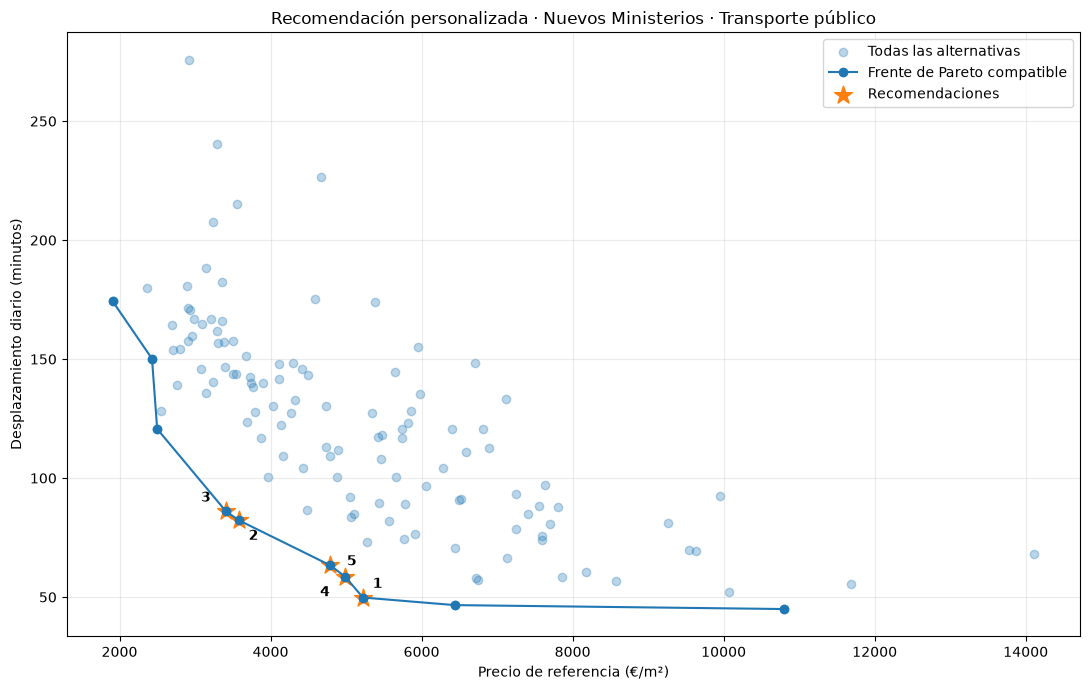

In [23]:
def plot_personalized_recommendation(
    data: pd.DataFrame,
    recommendations: pd.DataFrame,
    destination: str | int,
    transport_mode: str,
    max_price_m2: float | None = None,
    max_commute_daily_minutes: float | None = None,
    max_reference_budget_eur: float | None = None,
    reference_area_m2: float = 80.0,
    min_price_reliability_score: float | None = None,
) -> None:
    destination_id, destination_name = resolve_destination(
        data,
        destination,
    )
    resolved_mode, mode_label = resolve_transport_mode(
        data,
        transport_mode,
    )

    group_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
            & data["transport_mode"]
            .astype(str)
            .eq(str(resolved_mode))
        ]
        .copy()
    )

    group_data["reference_price_eur"] = (
        group_data[PRICE_COLUMN]
        * reference_area_m2
    )

    compatible = group_data.copy()

    if max_price_m2 is not None:
        compatible = compatible.loc[
            compatible[PRICE_COLUMN]
            <= max_price_m2
        ]

    if max_reference_budget_eur is not None:
        compatible = compatible.loc[
            compatible["reference_price_eur"]
            <= max_reference_budget_eur
        ]

    if max_commute_daily_minutes is not None:
        compatible = compatible.loc[
            compatible[TIME_COLUMN]
            <= max_commute_daily_minutes
        ]

    if min_price_reliability_score is not None:
        if "price_reliability_score" not in compatible.columns:
            raise KeyError(
                "No existe la columna price_reliability_score."
            )

        compatible = compatible.loc[
            compatible["price_reliability_score"].notna()
            & (
                compatible["price_reliability_score"]
                >= min_price_reliability_score
            )
        ]

    has_active_constraints = any(
        value is not None
        for value in [
            max_price_m2,
            max_commute_daily_minutes,
            max_reference_budget_eur,
            min_price_reliability_score,
        ]
    )

    if compatible.empty:
        compatible_front = compatible.copy()
    else:
        compatible = compatible.copy()
        compatible["is_pareto_eligible"] = (
            pareto_mask_minimization(
                compatible[
                    [PRICE_COLUMN, TIME_COLUMN]
                ].to_numpy(dtype=float)
            )
        )
        compatible_front = (
            compatible.loc[
                compatible["is_pareto_eligible"]
            ]
            .sort_values(PRICE_COLUMN)
        )

    plt.figure(figsize=(11, 7))

    plt.scatter(
        group_data[PRICE_COLUMN],
        group_data[TIME_COLUMN],
        alpha=0.30,
        label="Todas las alternativas",
    )

    if (
        has_active_constraints
        and not compatible.empty
    ):
        plt.scatter(
            compatible[PRICE_COLUMN],
            compatible[TIME_COLUMN],
            alpha=0.55,
            label="Alternativas compatibles",
        )

    if not compatible_front.empty:
        plt.plot(
            compatible_front[PRICE_COLUMN],
            compatible_front[TIME_COLUMN],
            marker="o",
            label="Frente de Pareto compatible",
        )

    if not recommendations.empty:
        plt.scatter(
            recommendations[PRICE_COLUMN],
            recommendations[TIME_COLUMN],
            marker="*",
            s=180,
            label="Recomendaciones",
        )

        label_offsets = [
            (7, 7),
            (7, -14),
            (-18, 7),
            (-18, -14),
            (12, 0),
        ]

        for position, (_, row) in enumerate(
            recommendations.iterrows()
        ):
            offset = label_offsets[
                position % len(label_offsets)
            ]

            plt.annotate(
                str(
                    int(
                        row["recommendation_rank"]
                    )
                ),
                (
                    row[PRICE_COLUMN],
                    row[TIME_COLUMN],
                ),
                xytext=offset,
                textcoords="offset points",
                fontweight="bold",
            )

    plt.xlabel("Precio de referencia (€/m²)")
    plt.ylabel("Desplazamiento diario (minutos)")
    plt.title(
        "Recomendación personalizada · "
        f"{destination_name} · {mode_label}"
    )
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_personalized_recommendation(
    data=pareto_data,
    recommendations=example_recommendations,
    destination=EXAMPLE_DESTINATION,
    transport_mode=EXAMPLE_TRANSPORT_MODE,
    max_price_m2=EXAMPLE_MAX_PRICE_M2,
    max_commute_daily_minutes=(
        EXAMPLE_MAX_COMMUTE_DAILY_MINUTES
    ),
    max_reference_budget_eur=(
        EXAMPLE_MAX_REFERENCE_BUDGET_EUR
    ),
    reference_area_m2=(
        EXAMPLE_REFERENCE_AREA_M2
    ),
    min_price_reliability_score=(
        EXAMPLE_MIN_PRICE_RELIABILITY_SCORE
    ),
)

## 10. Casos de uso ilustrativos con restricciones

Los casos son ejemplos reproducibles y **no proceden de una encuesta de preferencias**. Se incluyen cuatro configuraciones para comprobar el motor con los cuatro modos.

El presupuesto se interpreta como referencia territorial para una vivienda de 80 m².

In [24]:
USER_CASES = {
    "student_uc3m_transit": {
        "case_name": "Estudiante · UC3M · transporte público",
        "destination": "DEST_003",
        "transport_mode": "TRANSIT",
        "price_weight": 0.75,
        "time_weight": 0.25,
        "max_reference_budget_eur": 320_000,
        "max_commute_daily_minutes": 220,
        "reference_area_m2": 80,
        "min_price_reliability_score": 30,
    },
    "professional_nuevos_car": {
        "case_name": "Profesional · Nuevos Ministerios · coche",
        "destination": "DEST_002",
        "transport_mode": "CAR",
        "price_weight": 0.25,
        "time_weight": 0.75,
        "max_reference_budget_eur": 550_000,
        "max_commute_daily_minutes": 70,
        "reference_area_m2": 80,
        "min_price_reliability_score": 40,
    },
    "balanced_sol_bicycle": {
        "case_name": "Perfil equilibrado · Sol · bicicleta",
        "destination": "DEST_001",
        "transport_mode": "BICYCLE",
        "price_weight": 0.50,
        "time_weight": 0.50,
        "max_reference_budget_eur": 500_000,
        "max_commute_daily_minutes": 120,
        "reference_area_m2": 80,
        "min_price_reliability_score": 40,
    },
    "walk_sol": {
        "case_name": "Desplazamiento a pie · Sol",
        "destination": "DEST_001",
        "transport_mode": "WALK",
        "price_weight": 0.35,
        "time_weight": 0.65,
        "max_reference_budget_eur": 700_000,
        "max_commute_daily_minutes": 120,
        "reference_area_m2": 80,
        "min_price_reliability_score": 30,
    },
}

In [25]:
case_recommendation_frames = []
case_audit_frames = []

for case_id, case_config in USER_CASES.items():
    recommendations, audit = recommend_neighborhoods(
        data=pareto_data,
        destination=case_config["destination"],
        transport_mode=case_config["transport_mode"],
        price_weight=case_config["price_weight"],
        time_weight=case_config["time_weight"],
        top_n=5,
        max_reference_budget_eur=(
            case_config["max_reference_budget_eur"]
        ),
        max_commute_daily_minutes=(
            case_config["max_commute_daily_minutes"]
        ),
        reference_area_m2=case_config["reference_area_m2"],
        min_price_reliability_score=(
            case_config["min_price_reliability_score"]
        ),
        pareto_only=True,
    )

    audit.insert(0, "case_id", case_id)
    audit.insert(
        1,
        "case_name",
        case_config["case_name"],
    )
    case_audit_frames.append(audit)

    if not recommendations.empty:
        recommendations.insert(
            0,
            "case_id",
            case_id,
        )
        recommendations.insert(
            1,
            "case_name",
            case_config["case_name"],
        )
        case_recommendation_frames.append(
            recommendations
        )

case_audits = pd.concat(
    case_audit_frames,
    ignore_index=True,
)

case_recommendations = (
    pd.concat(
        case_recommendation_frames,
        ignore_index=True,
    )
    if case_recommendation_frames
    else pd.DataFrame()
)

display(case_audits)

,case_id,case_name,stage,remaining_alternatives,removed_alternatives,destination_id,destination_name,transport_mode,transport_mode_label
0,student_uc3m_transit,Estudiante · UC3M · transporte público,Combinación destino–modo seleccionada,128,0,DEST_003,UC3M Campus de Leganés,TRANSIT,Transporte público
1,student_uc3m_transit,Estudiante · UC3M · transporte público,Presupuesto orientativo máximo,45,83,DEST_003,UC3M Campus de Leganés,TRANSIT,Transporte público
2,student_uc3m_transit,Estudiante · UC3M · transporte público,Tiempo diario máximo,34,11,DEST_003,UC3M Campus de Leganés,TRANSIT,Transporte público
3,student_uc3m_transit,Estudiante · UC3M · transporte público,Fiabilidad mínima,24,10,DEST_003,UC3M Campus de Leganés,TRANSIT,Transporte público
4,student_uc3m_transit,Estudiante · UC3M · transporte público,Frente de Pareto compatible,4,20,DEST_003,UC3M Campus de Leganés,TRANSIT,Transporte público
5,professional_nuevos_car,Profesional · Nuevos Ministerios · coche,Combinación destino–modo seleccionada,121,0,DEST_002,Nuevos Ministerios,CAR,Coche
6,professional_nuevos_car,Profesional · Nuevos Ministerios · coche,Presupuesto orientativo máximo,96,25,DEST_002,Nuevos Ministerios,CAR,Coche
7,professional_nuevos_car,Profesional · Nuevos Ministerios · coche,Tiempo diario máximo,96,0,DEST_002,Nuevos Ministerios,CAR,Coche
8,professional_nuevos_car,Profesional · Nuevos Ministerios · coche,Fiabilidad mínima,55,41,DEST_002,Nuevos Ministerios,CAR,Coche
9,professional_nuevos_car,Profesional · Nuevos Ministerios · coche,Frente de Pareto compatible,10,45,DEST_002,Nuevos Ministerios,CAR,Coche


In [26]:
if case_recommendations.empty:
    display(
        Markdown(
            """
### No hay recomendaciones

Ninguno de los casos definidos ha producido alternativas compatibles.
"""
        )
    )
else:
    case_display_columns = [
        "case_name",
        "destination_name",
        "transport_mode_label",
        "recommendation_rank",
        "neighborhood_name",
        "district_name",
        PRICE_COLUMN,
        TIME_COLUMN,
        "reference_price_eur",
        "price_score_contribution",
        "time_score_contribution",
        "preference_score",
    ]

    if "price_reliability_score" in case_recommendations.columns:
        case_display_columns.append(
            "price_reliability_score"
        )

    display(
        case_recommendations[
            case_display_columns
        ].sort_values(
            [
                "case_name",
                "recommendation_rank",
            ]
        )
    )

    for case_id, case_data in (
        case_recommendations
        .groupby("case_id")
    ):
        case_name = (
            case_data["case_name"].iloc[0]
        )

        display(
            Markdown(
                f"### {case_name}"
            )
        )

        for _, row in (
            case_data
            .sort_values("recommendation_rank")
            .iterrows()
        ):
            display(
                Markdown(
                    f"**{int(row['recommendation_rank'])}. "
                    f"{row['neighborhood_name']}**  \n"
                    f"{row['recommendation_explanation']}"
                )
            )

,case_name,destination_name,transport_mode_label,recommendation_rank,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,reference_price_eur,price_score_contribution,time_score_contribution,preference_score,price_reliability_score
14,Desplazamiento a pie · Sol,Puerta del Sol,A pie,1,Embajadores,Centro,6054.75,26.933333,484380.0,0.118926,0.034948,0.153874,76.98
15,Desplazamiento a pie · Sol,Puerta del Sol,A pie,2,Sol,Centro,7696.61,3.700000,615728.8,0.166031,0.000000,0.166031,85.83
16,Desplazamiento a pie · Sol,Puerta del Sol,A pie,3,Puerta del Ángel,Latina,4033.30,79.716667,322664.0,0.060930,0.114346,0.175276,50.63
17,Desplazamiento a pie · Sol,Puerta del Sol,A pie,4,Cortes,Centro,7246.75,21.166667,579740.0,0.153125,0.026274,0.179398,60.56
18,Desplazamiento a pie · Sol,Puerta del Sol,A pie,5,Palos de la Frontera,Arganzuela,5784.65,55.966667,462772.0,0.111176,0.078621,0.189797,57.38
0,Estudiante · UC3M · transporte público,UC3M Campus de Leganés,Transporte público,1,San Cristóbal,Villaverde,1909.60,136.333333,152768.0,0.000000,0.076547,0.076547,36.67
1,Estudiante · UC3M · transporte público,UC3M Campus de Leganés,Transporte público,2,Puerta Bonita,Carabanchel,2905.06,77.750000,232404.8,0.061200,0.023613,0.084813,51.59
2,Estudiante · UC3M · transporte público,UC3M Campus de Leganés,Transporte público,3,Buenavista,Carabanchel,3291.57,51.616667,263325.6,0.084963,0.000000,0.084963,56.03
3,Estudiante · UC3M · transporte público,UC3M Campus de Leganés,Transporte público,4,Vista Alegre,Carabanchel,3213.22,74.283333,257057.6,0.080146,0.020481,0.100626,60.56
9,Perfil equilibrado · Sol · bicicleta,Puerta del Sol,Bicicleta,1,Puerta del Ángel,Latina,4033.30,30.266667,322664.0,0.087042,0.073694,0.160736,50.63


### Perfil equilibrado · Sol · bicicleta

**1. Puerta del Ángel**  
Puerta del Ángel ocupa la posición 1 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Puerta del Sol y desplazamiento en bicicleta. Su precio de referencia es 4,033.30 €/m² y el desplazamiento diario estimado es de 30.27 minutos. El precio está un 17.3 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 55.7 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.087 y la del tiempo es 0.074. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 50.63 sobre 100.

**2. Opañel**  
Opañel ocupa la posición 2 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Puerta del Sol y desplazamiento en bicicleta. Su precio de referencia es 3,500.89 €/m² y el desplazamiento diario estimado es de 43.23 minutos. El precio está un 28.2 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 36.7 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.065 y la del tiempo es 0.110. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 66.55 sobre 100.

**3. Moscardó**  
Moscardó ocupa la posición 3 para un perfil que busca un equilibrio parecido entre precio y desplazamiento, con destino Puerta del Sol y desplazamiento en bicicleta. Su precio de referencia es 3,739.18 €/m² y el desplazamiento diario estimado es de 40.90 minutos. El precio está un 23.4 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 40.2 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.075 y la del tiempo es 0.103. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como low. Su puntuación de fiabilidad es 40.95 sobre 100.

...

**1. Embajadores**  
Embajadores ocupa la posición 1 para un perfil que da más importancia al tiempo de desplazamiento, con destino Puerta del Sol y desplazamiento en a pie. Su precio de referencia es 6,054.75 €/m² y el desplazamiento diario estimado es de 26.93 minutos. El precio está un 24.0 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 84.1 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.119 y la del tiempo es 0.035. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como high. Su puntuación de fiabilidad es 76.98 sobre 100.

**2. Sol**  
Sol ocupa la posición 2 para un perfil que da más importancia al tiempo de desplazamiento, con destino Puerta del Sol y desplazamiento en a pie. Su precio de referencia es 7,696.61 €/m² y el desplazamiento diario estimado es de 3.70 minutos. El precio está un 57.6 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 97.8 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.166 y la del tiempo es 0.000. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como high. Su puntuación de fiabilidad es 85.83 sobre 100.

**3. Puerta del Ángel**  
Puerta del Ángel ocupa la posición 3 para un perfil que da más importancia al tiempo de desplazamiento, con destino Puerta del Sol y desplazamiento en a pie. Su precio de referencia es 4,033.30 €/m² y el desplazamiento diario estimado es de 79.72 minutos. El precio está un 17.4 % por debajo de la mediana de precio del grupo destino–modo y el tiempo está un 52.8 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.061 y la del tiempo es 0.114. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 50.63 sobre 100.

**4. Cortes**  
Cortes ocupa la posición 4 para un perfil que da más importancia al tiempo de desplazamiento, con destino Puerta del Sol y desplazamiento en a pie. Su precio de referencia es 7,246.75 €/m² y el desplazamiento diario estimado es de 21.17 minutos. El precio está un 48.4 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 87.5 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.153 y la del tiempo es 0.026. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 60.56 sobre 100.

**5. Palos de la Frontera**  
Palos de la Frontera ocupa la posición 5 para un perfil que da más importancia al tiempo de desplazamiento, con destino Puerta del Sol y desplazamiento en a pie. Su precio de referencia es 5,784.65 €/m² y el desplazamiento diario estimado es de 55.97 minutos. El precio está un 18.4 % por encima de la mediana de precio del grupo destino–modo y el tiempo está un 66.9 % por debajo de la mediana de tiempo del grupo destino–modo. La alternativa no está dominada dentro del conjunto compatible con las restricciones. En la puntuación final, la contribución normalizada del precio es 0.111 y la del tiempo es 0.079. También pertenecía al frente de Pareto general de esta combinación destino–modo. El nivel de fiabilidad de la estimación inmobiliaria está clasificado como medium. Su puntuación de fiabilidad es 57.38 sobre 100.

## 11. Comparación de perfiles en todas las combinaciones destino–modo

Cada perfil se evalúa independientemente para cada combinación *destino–modo*. Así se estudia cómo cambian las recomendaciones sin mezclar escalas de movilidad diferentes.

In [27]:
def build_profile_comparison(
    data: pd.DataFrame,
    profiles: dict,
    reference_area_m2: float = 80.0,
) -> pd.DataFrame:
    rows = []

    catalog = (
        data[
            [
                "destination_id",
                "destination_name",
                "transport_mode",
                "transport_mode_label",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            ["destination_id", "transport_mode"]
        )
    )

    for _, group_row in catalog.iterrows():
        for profile_id, profile in profiles.items():
            recommendations, _ = recommend_neighborhoods(
                data=data,
                destination=group_row["destination_id"],
                transport_mode=group_row["transport_mode"],
                price_weight=profile["price_weight"],
                time_weight=profile["time_weight"],
                top_n=1,
                reference_area_m2=reference_area_m2,
                pareto_only=True,
            )

            if recommendations.empty:
                rows.append(
                    {
                        "destination_id": group_row["destination_id"],
                        "destination_name": group_row["destination_name"],
                        "transport_mode": group_row["transport_mode"],
                        "transport_mode_label": group_row["transport_mode_label"],
                        "profile_id": profile_id,
                        "profile_name": profile["profile_name"],
                        "status": "no_recommendation",
                    }
                )
                continue

            selected = recommendations.iloc[0]

            row = {
                "destination_id": selected["destination_id"],
                "destination_name": selected["destination_name"],
                "transport_mode": selected["transport_mode"],
                "transport_mode_label": selected["transport_mode_label"],
                "profile_id": profile_id,
                "profile_name": profile["profile_name"],
                "price_weight": selected["price_weight"],
                "time_weight": selected["time_weight"],
                "zone_key": selected["zone_key"],
                "neighborhood_name": selected["neighborhood_name"],
                "district_name": selected["district_name"],
                PRICE_COLUMN: selected[PRICE_COLUMN],
                TIME_COLUMN: selected[TIME_COLUMN],
                "reference_price_eur": selected["reference_price_eur"],
                "preference_score": selected["preference_score"],
                "is_pareto": selected["is_pareto"],
                "is_pareto_eligible": selected["is_pareto_eligible"],
                "status": "recommended",
            }

            for optional_column in [
                "price_reliability_score",
                "price_reliability_level",
                "price_m2_for_recommender_source",
            ]:
                if optional_column in recommendations.columns:
                    row[optional_column] = (
                        selected[optional_column]
                    )

            rows.append(row)

    return pd.DataFrame(rows)


profile_comparison = build_profile_comparison(
    data=pareto_data,
    profiles=PREDEFINED_PROFILES,
    reference_area_m2=EXAMPLE_REFERENCE_AREA_M2,
)

display(profile_comparison)

,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,reference_price_eur,preference_score,is_pareto,is_pareto_eligible,status,price_reliability_score,price_reliability_level,price_m2_for_recommender_source
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,Usera,2357.51,73.716667,188600.8,0.124648,True,True,recommended,10.58,low,registered_transactions_2025
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,30.266667,322664.0,0.160736,True,True,recommended,50.63,medium,registered_transactions_2025
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.25,0.75,MAD-016,Sol,Centro,7696.61,3.700000,615728.8,0.118594,True,True,recommended,85.83,high,registered_transactions_2025
3,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,Usera,2357.51,28.416667,188600.8,0.115396,True,True,recommended,10.58,low,registered_transactions_2025
4,DEST_001,Puerta del Sol,CAR,Coche,balanced,Perfil equilibrado,0.50,0.50,MAD-134,Palomeras Sureste,Puente de Vallecas,2701.36,24.366667,216108.8,0.171103,True,True,recommended,59.11,medium,registered_transactions_2025
5,DEST_001,Puerta del Sol,CAR,Coche,time_priority,Prioridad al tiempo,0.25,0.75,MAD-015,Universidad,Centro,7135.43,10.000000,570834.4,0.117847,True,True,recommended,83.81,high,registered_transactions_2025
6,DEST_001,Puerta del Sol,TRANSIT,Transporte público,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,139.716667,152768.0,0.110749,True,True,recommended,36.67,low,registered_transactions_2025
7,DEST_001,Puerta del Sol,TRANSIT,Transporte público,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,65.133333,322664.0,0.110339,True,True,recommended,50.63,medium,registered_transactions_2025
8,DEST_001,Puerta del Sol,TRANSIT,Transporte público,time_priority,Prioridad al tiempo,0.25,0.75,MAD-102,Puerta del Ángel,Latina,4033.30,65.133333,322664.0,0.078467,True,True,recommended,50.63,medium,registered_transactions_2025
9,DEST_001,Puerta del Sol,WALK,A pie,price_priority,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,Usera,2357.51,184.066667,188600.8,0.131888,True,True,recommended,10.58,low,registered_transactions_2025


In [28]:
profile_recommendation_matrix = (
    profile_comparison
    .pivot(
        index=[
            "destination_name",
            "transport_mode_label",
        ],
        columns="profile_name",
        values="neighborhood_name",
    )
)

display(profile_recommendation_matrix)

profile_diversity = (
    profile_comparison.loc[
        profile_comparison["status"].eq(
            "recommended"
        )
    ]
    .groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        recommended_profiles=(
            "profile_id",
            "nunique",
        ),
        different_top_neighborhoods=(
            "zone_key",
            "nunique",
        ),
    )
    .sort_values(
        [
            "different_top_neighborhoods",
            "destination_id",
            "transport_mode",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
)

display(profile_diversity)

profile_name                                                              Perfil equilibrado Prioridad al precio                              Prioridad al tiempo
destination_name       transport_mode_label                                                                                                                      
Nuevos Ministerios     A pie                                                      Berruguete             Amposta                                   Cuatro Caminos
                       Bicicleta                                               Bellas Vistas             Amposta                                   Cuatro Caminos
                       Coche                                                        Almenara             Amposta                                   Cuatro Caminos
                       Transporte público                                      Bellas Vistas              Hellín                                    Bellas Vistas
Puerta del Sol         A pie                                                Puerta del Ángel           Orcasitas                                              Sol
                       Bicicleta                                            Puerta del Ángel           Orcasitas                                              Sol
                       Coche                                               Palomeras Sureste           Orcasitas                                      Universidad
                       Transporte público                                   Puerta del Ángel       San Cristóbal                                 Puerta del Ángel
UC3M Campus de Leganés A pie                 Villaverde Alto - Casco Histórico de Villaverde       San Cristóbal                                       Buenavista
                       Bicicleta             Villaverde Alto - Casco Histórico de Villaverde       San Cristóbal  Villaverde Alto - Casco Histórico de Villaverde
                       Coche                                                      Buenavista       San Cristóbal                                       Buenavista
                       Transporte público                                         Buenavista       San Cristóbal                                       Buenavista

,destination_id,destination_name,transport_mode,transport_mode_label,recommended_profiles,different_top_neighborhoods
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,3,3
1,DEST_001,Puerta del Sol,CAR,Coche,3,3
3,DEST_001,Puerta del Sol,WALK,A pie,3,3
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,3,3
5,DEST_002,Nuevos Ministerios,CAR,Coche,3,3
7,DEST_002,Nuevos Ministerios,WALK,A pie,3,3
11,DEST_003,UC3M Campus de Leganés,WALK,A pie,3,3
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,3,2
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,3,2
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,3,2


## 12. Validaciones sistemáticas

Se validan de forma independiente unicidad, cobertura, eficiencia Pareto, determinismo, orden, fórmula de scoring, pesos extremos, entradas inválidas y conservación de la auditoría.

In [29]:
def raises_expected_error(
    function,
    expected_exception: type[Exception],
) -> bool:
    try:
        function()
    except expected_exception:
        return True
    except Exception:
        return False
    return False


def find_dominators(
    data: pd.DataFrame,
    destination_id: str | int,
    transport_mode: str,
    zone_key: str,
    tolerance: float = 1e-9,
) -> pd.DataFrame:
    group_data = (
        data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
            & data["transport_mode"]
            .astype(str)
            .eq(str(transport_mode))
        ]
        .copy()
    )

    selected_rows = group_data.loc[
        group_data["zone_key"]
        .astype(str)
        .eq(str(zone_key))
    ]

    if selected_rows.empty:
        raise KeyError(
            "No se ha encontrado la alternativa "
            f"{zone_key} para {destination_id} / {transport_mode}."
        )

    if len(selected_rows) > 1:
        raise ValueError(
            "La combinación barrio–destino–modo no es única."
        )

    selected = selected_rows.iloc[0]
    selected_price = float(
        selected[PRICE_COLUMN]
    )
    selected_time = float(
        selected[TIME_COLUMN]
    )

    no_worse_price = (
        group_data[PRICE_COLUMN]
        <= selected_price + tolerance
    )
    no_worse_time = (
        group_data[TIME_COLUMN]
        <= selected_time + tolerance
    )
    strictly_better_price = (
        group_data[PRICE_COLUMN]
        < selected_price - tolerance
    )
    strictly_better_time = (
        group_data[TIME_COLUMN]
        < selected_time - tolerance
    )

    return (
        group_data.loc[
            no_worse_price
            & no_worse_time
            & (
                strictly_better_price
                | strictly_better_time
            )
        ]
        .copy()
    )

In [30]:
def build_validation_report(
    data: pd.DataFrame,
    profile_comparison_data: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    def add(
        validation_id: str,
        description: str,
        passed: bool,
        detail: str,
    ) -> None:
        rows.append(
            {
                "validation_id": validation_id,
                "description": description,
                "passed": bool(passed),
                "detail": detail,
            }
        )

    duplicates = int(
        data.duplicated(
            subset=ALTERNATIVE_KEY
        ).sum()
    )
    add(
        "unique_alternatives",
        "No hay combinaciones barrio–destino–modo duplicadas.",
        duplicates == 0,
        f"Duplicados detectados: {duplicates}",
    )

    observed_modes = set(
        data["transport_mode"]
        .astype(str)
        .unique()
    )
    add(
        "expected_transport_modes",
        "Están presentes exactamente los cuatro modos previstos.",
        observed_modes == set(EXPECTED_MODES),
        f"Presentes: {sorted(observed_modes)}",
    )

    number_of_groups = (
        data[GROUP_KEY]
        .drop_duplicates()
        .shape[0]
    )
    expected_profile_rows = (
        number_of_groups
        * len(PREDEFINED_PROFILES)
    )
    generated_profile_rows = len(
        profile_comparison_data
    )
    complete_profile_rows = int(
        profile_comparison_data["status"]
        .eq("recommended")
        .sum()
    )
    profile_coverage_ok = (
        generated_profile_rows
        == expected_profile_rows
        and complete_profile_rows
        == expected_profile_rows
    )
    add(
        "profile_coverage",
        "Existe una recomendación por perfil para cada combinación destino–modo.",
        profile_coverage_ok,
        (
            f"Esperadas: {expected_profile_rows}; "
            f"generadas: {generated_profile_rows}; "
            f"completas: {complete_profile_rows}"
        ),
    )

    pareto_violations = []

    recommended_profiles = (
        profile_comparison_data.loc[
            profile_comparison_data["status"]
            .eq("recommended")
        ]
    )

    for _, recommendation in (
        recommended_profiles.iterrows()
    ):
        dominators = find_dominators(
            data=data,
            destination_id=(
                recommendation["destination_id"]
            ),
            transport_mode=(
                recommendation["transport_mode"]
            ),
            zone_key=(
                recommendation["zone_key"]
            ),
        )

        if not dominators.empty:
            pareto_violations.append(
                {
                    "destination_id": recommendation["destination_id"],
                    "transport_mode": recommendation["transport_mode"],
                    "profile_id": recommendation["profile_id"],
                    "zone_key": recommendation["zone_key"],
                    "number_of_dominators": len(dominators),
                }
            )

    add(
        "independent_pareto_efficiency",
        "Ninguna recomendación de perfil está dominada dentro de su grupo destino–modo.",
        len(pareto_violations) == 0,
        (
            "Recomendaciones dominadas: "
            f"{len(pareto_violations)}"
        ),
    )

    test_group = (
        data[
            ["destination_id", "transport_mode"]
        ]
        .drop_duplicates()
        .sort_values(
            ["destination_id", "transport_mode"]
        )
        .iloc[0]
    )

    test_destination = (
        test_group["destination_id"]
    )
    test_mode = (
        test_group["transport_mode"]
    )

    first_run, _ = recommend_neighborhoods(
        data=data,
        destination=test_destination,
        transport_mode=test_mode,
        price_weight=0.63,
        time_weight=0.37,
        top_n=10,
    )
    second_run, _ = recommend_neighborhoods(
        data=data,
        destination=test_destination,
        transport_mode=test_mode,
        price_weight=0.63,
        time_weight=0.37,
        top_n=10,
    )

    comparison_columns = [
        "zone_key",
        "recommendation_rank",
        "preference_score",
    ]
    deterministic = (
        first_run[comparison_columns]
        .equals(
            second_run[comparison_columns]
        )
    )
    add(
        "determinism",
        "La misma configuración produce exactamente el mismo ranking.",
        deterministic,
        (
            f"Grupo de prueba: "
            f"{test_destination} / {test_mode}"
        ),
    )

    score_order_valid = (
        first_run["preference_score"]
        .is_monotonic_increasing
    )
    add(
        "score_order",
        "El ranking está ordenado de menor a mayor puntuación.",
        score_order_valid,
        (
            "Puntuaciones: "
            f"{first_run['preference_score'].round(6).tolist()}"
        ),
    )

    expected_scores = (
        first_run["price_weight"]
        * first_run["price_normalized"]
        + first_run["time_weight"]
        * first_run["time_normalized"]
    )
    score_formula_ok = np.allclose(
        first_run["preference_score"],
        expected_scores,
        atol=1e-12,
        rtol=1e-12,
    )
    max_score_difference = float(
        np.max(
            np.abs(
                first_run["preference_score"]
                - expected_scores
            )
        )
    )
    add(
        "score_formula",
        "La puntuación coincide con la combinación ponderada definida.",
        score_formula_ok,
        f"Máxima diferencia: {max_score_difference:.3e}",
    )

    expected_ranks = list(
        range(1, len(first_run) + 1)
    )
    ranks_ok = (
        first_run["recommendation_rank"]
        .tolist()
        == expected_ranks
    )
    add(
        "consecutive_ranks",
        "Los rangos son consecutivos y comienzan en 1.",
        ranks_ok,
        (
            f"Rangos: "
            f"{first_run['recommendation_rank'].tolist()}"
        ),
    )

    price_extreme_ok = True
    time_extreme_ok = True
    extreme_details = []

    for _, group_row in (
        data[
            ["destination_id", "transport_mode"]
        ]
        .drop_duplicates()
        .iterrows()
    ):
        destination_id = (
            group_row["destination_id"]
        )
        transport_mode = (
            group_row["transport_mode"]
        )

        price_result, _ = recommend_neighborhoods(
            data=data,
            destination=destination_id,
            transport_mode=transport_mode,
            price_weight=1,
            time_weight=0,
            top_n=len(data),
            pareto_only=True,
        )
        time_result, _ = recommend_neighborhoods(
            data=data,
            destination=destination_id,
            transport_mode=transport_mode,
            price_weight=0,
            time_weight=1,
            top_n=len(data),
            pareto_only=True,
        )

        group_data = data.loc[
            data["destination_id"]
            .astype(str)
            .eq(str(destination_id))
            & data["transport_mode"]
            .astype(str)
            .eq(str(transport_mode))
        ]

        price_ok = (
            not price_result.empty
            and np.isclose(
                float(
                    price_result.iloc[0][PRICE_COLUMN]
                ),
                float(
                    group_data[PRICE_COLUMN].min()
                ),
            )
        )
        time_ok = (
            not time_result.empty
            and np.isclose(
                float(
                    time_result.iloc[0][TIME_COLUMN]
                ),
                float(
                    group_data[TIME_COLUMN].min()
                ),
            )
        )

        price_extreme_ok = (
            price_extreme_ok and price_ok
        )
        time_extreme_ok = (
            time_extreme_ok and time_ok
        )

        extreme_details.append(
            f"{destination_id}/{transport_mode}: "
            f"precio={price_ok}, tiempo={time_ok}"
        )

    add(
        "price_extreme",
        "Con 100 % de peso en precio se selecciona un mínimo de precio del grupo.",
        price_extreme_ok,
        " | ".join(extreme_details),
    )
    add(
        "time_extreme",
        "Con 100 % de peso en tiempo se selecciona un mínimo de tiempo del grupo.",
        time_extreme_ok,
        " | ".join(extreme_details),
    )

    negative_weight_rejected = raises_expected_error(
        lambda: recommend_neighborhoods(
            data=data,
            destination=test_destination,
            transport_mode=test_mode,
            price_weight=-1,
            time_weight=1,
        ),
        ValueError,
    )
    add(
        "negative_weight_rejected",
        "Los pesos negativos se rechazan.",
        negative_weight_rejected,
        "Se espera ValueError.",
    )

    zero_weights_rejected = raises_expected_error(
        lambda: recommend_neighborhoods(
            data=data,
            destination=test_destination,
            transport_mode=test_mode,
            price_weight=0,
            time_weight=0,
        ),
        ValueError,
    )
    add(
        "zero_weights_rejected",
        "Se rechaza una configuración con ambos pesos iguales a cero.",
        zero_weights_rejected,
        "Se espera ValueError.",
    )

    unknown_destination_rejected = (
        raises_expected_error(
            lambda: recommend_neighborhoods(
                data=data,
                destination="DESTINO_INEXISTENTE",
                transport_mode=test_mode,
                price_weight=0.5,
                time_weight=0.5,
            ),
            KeyError,
        )
    )
    add(
        "unknown_destination_rejected",
        "Los destinos inexistentes se rechazan.",
        unknown_destination_rejected,
        "Se espera KeyError.",
    )

    unknown_mode_rejected = (
        raises_expected_error(
            lambda: recommend_neighborhoods(
                data=data,
                destination=test_destination,
                transport_mode="MODO_INEXISTENTE",
                price_weight=0.5,
                time_weight=0.5,
            ),
            KeyError,
        )
    )
    add(
        "unknown_mode_rejected",
        "Los modos inexistentes se rechazan.",
        unknown_mode_rejected,
        "Se espera KeyError.",
    )

    empty_result, empty_audit = (
        recommend_neighborhoods(
            data=data,
            destination=test_destination,
            transport_mode=test_mode,
            price_weight=0.5,
            time_weight=0.5,
            max_price_m2=1,
        )
    )
    empty_set_handled = (
        empty_result.empty
        and not empty_audit.empty
        and {
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        }.issubset(
            empty_audit.columns
        )
        and (
            empty_audit["remaining_alternatives"]
            .iloc[-1]
            == 0
        )
    )
    add(
        "empty_set_handled",
        "Las restricciones imposibles se gestionan sin perder la auditoría.",
        empty_set_handled,
        (
            f"Alternativas: {len(empty_result)}; "
            f"filas de auditoría: {len(empty_audit)}"
        ),
    )

    explanations_ok = (
        not first_run.empty
        and first_run[
            "recommendation_explanation"
        ]
        .astype(str)
        .str.len()
        .gt(50)
        .all()
    )
    add(
        "non_empty_explanations",
        "Las recomendaciones de prueba contienen una explicación sustantiva.",
        explanations_ok,
        (
            f"Recomendaciones comprobadas: {len(first_run)}"
        ),
    )

    return pd.DataFrame(rows)

In [31]:
validation_report = build_validation_report(
    data=pareto_data,
    profile_comparison_data=profile_comparison,
)

display(validation_report)

failed_validations = (
    validation_report.loc[
        ~validation_report["passed"]
    ]
)

if not failed_validations.empty:
    display(
        Markdown(
            "### Validaciones no superadas"
        )
    )
    display(failed_validations)
    raise AssertionError(
        "El recomendador multimodal no ha "
        "superado todas las validaciones."
    )

print(
    "Todas las validaciones del recomendador "
    "multimodal se han superado correctamente."
)

,validation_id,description,passed,detail
0,unique_alternatives,No hay combinaciones barrio–destino–modo duplicadas.,True,Duplicados detectados: 0
1,expected_transport_modes,Están presentes exactamente los cuatro modos previstos.,True,"Presentes: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
2,profile_coverage,Existe una recomendación por perfil para cada combinación destino–modo.,True,Esperadas: 36; generadas: 36; completas: 36
3,independent_pareto_efficiency,Ninguna recomendación de perfil está dominada dentro de su grupo destino–modo.,True,Recomendaciones dominadas: 0
4,determinism,La misma configuración produce exactamente el mismo ranking.,True,Grupo de prueba: DEST_001 / BICYCLE
5,score_order,El ranking está ordenado de menor a mayor puntuación.,True,"Puntuaciones: [0.153043, 0.159717, 0.163329, 0.164207, 0.164366, 0.166193, 0.166855, 0.170845, 0.178817, 0.187275]"
6,score_formula,La puntuación coincide con la combinación ponderada definida.,True,Máxima diferencia: 0.000e+00
7,consecutive_ranks,Los rangos son consecutivos y comienzan en 1.,True,"Rangos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
8,price_extreme,Con 100 % de peso en precio se selecciona un mínimo de precio del grupo.,True,"DEST_001/BICYCLE: precio=True, tiempo=True | DEST_001/CAR: precio=True, tiempo=True | DEST_001/TRANSIT: precio=True, tiempo=True | DEST_001/WALK: precio=True, tiempo=True | DES..."
9,time_extreme,Con 100 % de peso en tiempo se selecciona un mínimo de tiempo del grupo.,True,"DEST_001/BICYCLE: precio=True, tiempo=True | DEST_001/CAR: precio=True, tiempo=True | DEST_001/TRANSIT: precio=True, tiempo=True | DEST_001/WALK: precio=True, tiempo=True | DES..."


Todas las validaciones del recomendador multimodal se han superado correctamente.


## 13. Sensibilidad frente a los pesos

Se modifica el peso del precio desde 0 hasta 1 en pasos de 0,05. El peso del tiempo se ajusta para que ambos sumen 1.

Los intervalos son aproximados, porque se evalúa una malla discreta. Sirven para identificar estabilidad del ranking, no el punto matemático exacto de cada cambio. El análisis se realiza independientemente para cada combinación destino–modo.

In [32]:
def build_weight_sensitivity(
    data: pd.DataFrame,
    destination: str | int,
    transport_mode: str,
    step: float = 0.05,
) -> pd.DataFrame:
    if not (0 < step <= 1):
        raise ValueError(
            "step debe estar entre 0 y 1."
        )

    number_of_steps = int(
        round(1 / step)
    )
    rows = []

    for price_weight in np.linspace(
        0,
        1,
        number_of_steps + 1,
    ):
        time_weight = 1 - price_weight

        recommendations, _ = (
            recommend_neighborhoods(
                data=data,
                destination=destination,
                transport_mode=transport_mode,
                price_weight=price_weight,
                time_weight=time_weight,
                top_n=1,
                pareto_only=True,
            )
        )

        if recommendations.empty:
            continue

        selected = recommendations.iloc[0]

        rows.append(
            {
                "destination_id": selected["destination_id"],
                "destination_name": selected["destination_name"],
                "transport_mode": selected["transport_mode"],
                "transport_mode_label": selected["transport_mode_label"],
                "price_weight": round(
                    float(price_weight),
                    10,
                ),
                "time_weight": round(
                    float(time_weight),
                    10,
                ),
                "zone_key": selected["zone_key"],
                "neighborhood_name": selected["neighborhood_name"],
                "district_name": selected["district_name"],
                PRICE_COLUMN: selected[PRICE_COLUMN],
                TIME_COLUMN: selected[TIME_COLUMN],
                "preference_score": selected["preference_score"],
            }
        )

    return pd.DataFrame(rows)


def summarize_sensitivity_intervals(
    sensitivity_data: pd.DataFrame,
) -> pd.DataFrame:
    if sensitivity_data.empty:
        return sensitivity_data.copy()

    ordered = (
        sensitivity_data
        .sort_values("price_weight")
        .reset_index(drop=True)
        .copy()
    )

    ordered["recommendation_change"] = (
        ordered["zone_key"]
        .ne(
            ordered["zone_key"].shift()
        )
    )
    ordered["interval_id"] = (
        ordered["recommendation_change"]
        .cumsum()
    )

    return (
        ordered
        .groupby(
            "interval_id",
            as_index=False,
        )
        .agg(
            destination_id=("destination_id", "first"),
            destination_name=("destination_name", "first"),
            transport_mode=("transport_mode", "first"),
            transport_mode_label=("transport_mode_label", "first"),
            min_price_weight=("price_weight", "min"),
            max_price_weight=("price_weight", "max"),
            min_time_weight=("time_weight", "min"),
            max_time_weight=("time_weight", "max"),
            zone_key=("zone_key", "first"),
            neighborhood_name=("neighborhood_name", "first"),
            district_name=("district_name", "first"),
            price_eur_m2=(PRICE_COLUMN, "first"),
            commute_daily_minutes=(TIME_COLUMN, "first"),
            evaluated_weight_points=("price_weight", "size"),
        )
    )

In [33]:
weight_sensitivity_example = (
    build_weight_sensitivity(
        data=pareto_data,
        destination=EXAMPLE_DESTINATION,
        transport_mode=EXAMPLE_TRANSPORT_MODE,
        step=0.05,
    )
)

sensitivity_intervals_example = (
    summarize_sensitivity_intervals(
        weight_sensitivity_example
    )
)

display(weight_sensitivity_example)
display(sensitivity_intervals_example)

,destination_id,destination_name,transport_mode,transport_mode_label,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,preference_score
0,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.00,1.00,MAD-074,Almagro,Chamberí,10795.41,44.966667,0.000000
1,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.05,0.95,MAD-063,Castillejos,Tetuán,6438.00,46.616667,0.025351
2,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.10,0.90,MAD-063,Castillejos,Tetuán,6438.00,46.616667,0.043554
3,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.15,0.85,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.058552
4,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.20,0.80,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.071089
5,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.25,0.75,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.083626
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.30,0.70,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.096163
7,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.35,0.65,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.108700
8,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.40,0.60,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.121237
9,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.45,0.55,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,0.133774


,interval_id,destination_id,destination_name,transport_mode,transport_mode_label,min_price_weight,max_price_weight,min_time_weight,max_time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,evaluated_weight_points
0,1,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.00,0.00,1.00,1.00,MAD-074,Almagro,Chamberí,10795.41,44.966667,1
1,2,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.05,0.10,0.90,0.95,MAD-063,Castillejos,Tetuán,6438.00,46.616667,2
2,3,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.15,0.50,0.50,0.85,MAD-061,Bellas Vistas,Tetuán,5223.92,49.800000,8
3,4,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.55,0.65,0.35,0.45,MAD-207,Canillejas,San Blas - Canillejas,3409.64,86.016667,3
4,5,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.70,0.80,0.20,0.30,MAD-202,Hellín,San Blas - Canillejas,2498.86,120.650000,3
5,6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,0.85,1.00,0.00,0.15,MAD-172,San Cristóbal,Villaverde,1909.60,174.283333,4


In [34]:
all_sensitivity_frames = []
all_interval_frames = []

for _, group_row in (
    destination_mode_catalog.iterrows()
):
    group_sensitivity = (
        build_weight_sensitivity(
            data=pareto_data,
            destination=group_row["destination_id"],
            transport_mode=group_row["transport_mode"],
            step=0.05,
        )
    )
    group_intervals = (
        summarize_sensitivity_intervals(
            group_sensitivity
        )
    )

    all_sensitivity_frames.append(
        group_sensitivity
    )
    all_interval_frames.append(
        group_intervals
    )

weight_sensitivity_all_groups = (
    pd.concat(
        all_sensitivity_frames,
        ignore_index=True,
    )
)

sensitivity_intervals_all_groups = (
    pd.concat(
        all_interval_frames,
        ignore_index=True,
    )
)

sensitivity_summary = (
    sensitivity_intervals_all_groups
    .groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        different_recommended_neighborhoods=(
            "zone_key",
            "nunique",
        ),
        approximate_stability_intervals=(
            "interval_id",
            "count",
        ),
    )
    .sort_values(
        [
            "different_recommended_neighborhoods",
            "destination_id",
            "transport_mode",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
)

display(sensitivity_intervals_all_groups)
display(sensitivity_summary)

,interval_id,destination_id,destination_name,transport_mode,transport_mode_label,min_price_weight,max_price_weight,min_time_weight,max_time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,evaluated_weight_points
0,1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.00,0.30,0.70,1.00,MAD-016,Sol,Centro,7696.61,3.700000,7
1,2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.35,0.55,0.45,0.65,MAD-102,Puerta del Ángel,Latina,4033.30,30.266667,5
2,3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.60,0.70,0.30,0.40,MAD-123,San Fermín,Usera,2755.18,56.983333,3
3,4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.75,0.75,0.25,0.25,MAD-121,Orcasitas,Usera,2357.51,73.716667,1
4,5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,0.80,1.00,0.00,0.20,MAD-172,San Cristóbal,Villaverde,1909.60,94.933333,5
5,1,DEST_001,Puerta del Sol,CAR,Coche,0.00,0.05,0.95,1.00,MAD-014,Justicia,Centro,9541.90,9.216667,2
6,2,DEST_001,Puerta del Sol,CAR,Coche,0.10,0.40,0.60,0.90,MAD-015,Universidad,Centro,7135.43,10.000000,7
7,3,DEST_001,Puerta del Sol,CAR,Coche,0.45,0.45,0.55,0.55,MAD-144,Media Legua,Moratalaz,3876.72,20.016667,1
8,4,DEST_001,Puerta del Sol,CAR,Coche,0.50,0.70,0.30,0.50,MAD-134,Palomeras Sureste,Puente de Vallecas,2701.36,24.366667,5
9,5,DEST_001,Puerta del Sol,CAR,Coche,0.75,0.85,0.15,0.25,MAD-121,Orcasitas,Usera,2357.51,28.416667,3


,destination_id,destination_name,transport_mode,transport_mode_label,different_recommended_neighborhoods,approximate_stability_intervals
3,DEST_001,Puerta del Sol,WALK,A pie,7,7
1,DEST_001,Puerta del Sol,CAR,Coche,6,6
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,6,6
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,6,6
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,5,5
5,DEST_002,Nuevos Ministerios,CAR,Coche,5,5
7,DEST_002,Nuevos Ministerios,WALK,A pie,5,5
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,4,4
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,3,3
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,3,3


## 14. Exportación y resumen final

In [35]:
example_recommendations.to_csv(
    RECOMMENDATION_EXAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)
example_audit.to_csv(
    FILTER_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)
profile_definitions.to_csv(
    PROFILE_DEFINITIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)
profile_comparison.to_csv(
    PROFILE_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)
case_recommendations.to_csv(
    USER_CASE_RECOMMENDATIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)
case_audits.to_csv(
    USER_CASE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)
weight_sensitivity_example.to_csv(
    SENSITIVITY_EXAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)
sensitivity_intervals_example.to_csv(
    SENSITIVITY_INTERVALS_PATH,
    index=False,
    encoding="utf-8-sig",
)
weight_sensitivity_all_groups.to_csv(
    SENSITIVITY_ALL_GROUPS_PATH,
    index=False,
    encoding="utf-8-sig",
)
sensitivity_intervals_all_groups.to_csv(
    SENSITIVITY_INTERVALS_ALL_GROUPS_PATH,
    index=False,
    encoding="utf-8-sig",
)
sensitivity_summary.to_csv(
    SENSITIVITY_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
validation_report.to_csv(
    VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)

In [36]:
final_summary = pd.Series(
    {
        "rows_received_from_pareto": len(pareto_data),
        "neighborhoods_available": pareto_data["zone_key"].nunique(),
        "destinations": pareto_data["destination_id"].nunique(),
        "transport_modes": pareto_data["transport_mode"].nunique(),
        "destination_mode_groups": destination_mode_catalog.shape[0],
        "predefined_profiles": len(PREDEFINED_PROFILES),
        "profile_recommendations": int(
            profile_comparison["status"]
            .eq("recommended")
            .sum()
        ),
        "illustrative_user_cases": len(USER_CASES),
        "user_case_recommendations": len(case_recommendations),
        "sensitivity_weight_points": len(
            weight_sensitivity_all_groups
        ),
        "sensitivity_intervals": len(
            sensitivity_intervals_all_groups
        ),
        "validations": len(validation_report),
        "failed_validations": int(
            (~validation_report["passed"]).sum()
        ),
    },
    name="value",
).to_frame()

final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    encoding="utf-8-sig",
)

display(final_summary)

,value
rows_received_from_pareto,1457
neighborhoods_available,129
destinations,3
transport_modes,4
destination_mode_groups,12
predefined_profiles,3
profile_recommendations,36
illustrative_user_cases,4
user_case_recommendations,19
sensitivity_weight_points,252


In [37]:
generated_paths = [
    RECOMMENDATION_EXAMPLE_PATH,
    FILTER_AUDIT_PATH,
    PROFILE_DEFINITIONS_PATH,
    PROFILE_COMPARISON_PATH,
    USER_CASE_RECOMMENDATIONS_PATH,
    USER_CASE_AUDIT_PATH,
    SENSITIVITY_EXAMPLE_PATH,
    SENSITIVITY_INTERVALS_PATH,
    SENSITIVITY_ALL_GROUPS_PATH,
    SENSITIVITY_INTERVALS_ALL_GROUPS_PATH,
    SENSITIVITY_SUMMARY_PATH,
    VALIDATION_PATH,
    FINAL_SUMMARY_PATH,
]

missing_exports = [
    path
    for path in generated_paths
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado correctamente todos "
        f"los archivos: {missing_exports}"
    )

if not validation_report["passed"].all():
    raise AssertionError(
        "Existen validaciones no superadas."
    )

print("Archivos generados correctamente:")

for path in generated_paths:
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )

print(
    "\nNotebook 09 multimodal finalizado correctamente."
)

Archivos generados correctamente:
- data/results/personalized_recommendation_multimodal_example.csv
- data/results/personalized_recommendation_multimodal_filter_audit.csv
- data/results/recommendation_profiles.csv
- data/results/profile_recommendation_comparison_by_destination_mode.csv
- data/results/user_case_recommendations_multimodal.csv
- data/results/user_case_filter_audit_multimodal.csv
- data/results/recommendation_weight_sensitivity_multimodal_example.csv
- data/results/recommendation_weight_sensitivity_multimodal_example_intervals.csv
- data/results/recommendation_weight_sensitivity_all_destination_modes.csv
- data/results/recommendation_weight_sensitivity_intervals_all_destination_modes.csv
- data/results/recommendation_weight_sensitivity_summary_by_destination_mode.csv
- data/results/recommendation_engine_multimodal_validation.csv
- data/results/recommendation_engine_multimodal_summary.csv

Notebook 09 multimodal finalizado correctamente.


## 15. Conclusiones

El usuario puede elegir destino, modo de transporte, presupuesto, tiempo máximo y cuánto prioriza precio o tiempo. A partir de eso, el sistema filtra las opciones válidas, aplica Pareto y genera un ranking con las alternativas que mejor encajan.

Cada recomendación incluye una explicación sencilla de por qué aparece en esa posición, y también se comprueba cómo cambia el resultado cuando cambian los pesos.

Esto resulta en un recomendador multimodal centrado en el equilibrio entre precio y tiempo de desplazamiento, adaptado a las preferencias de cada usuario.